## Example 3a:
Exploratory study of how the uncertainty in the predicted aberrations depends on how far the beam is from focus.

We now take a break from ML to do some physics.

A mixed-density model is fitted on single-z images, similarly to in [`zstack_decoding/example_2d.ipynb`](zstack_decoding/example_2d.ipynb).
The model is then used to simulate a batch of z-stacks and their true, underlying aberrations. Single-z images from those z-stacks are then run through inference, and the predicted uncertainty for each coefficient is plotted as a function of defocus through each z-stack. These predicted uncertainties can then be compared to their priors and the van Trees limit at each z-position.

In [1]:
import itertools
import logging
import math
import warnings

import numpy as np
import torch
import pytorch_lightning as pl
from lightning_fabric.utilities.warnings import PossibleUserWarning
from matplotlib import pyplot

In [2]:
# Silence a few nuisance warnings:
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=PossibleUserWarning)
warnings.filterwarnings("ignore", message="Starting from v1.9.0, `tensorboardX`")
warnings.filterwarnings("ignore", message=r".*isinstance\(treespec, LeafSpec\).*")

In [3]:
from cynosure.config_defaults import (
    get_default_training_config,
    get_default_simulation_config,
    get_default_optical_config,
    get_default_phase_config,
    get_default_amplitude_config,
    get_default_phase_prior,
    get_default_amplitude_prior,
    get_default_noise_config,
    get_default_mixture_config,
)
from cynosure.object_distribution import FixedBead
from cynosure.utilities.training_utils import NoValidationBar
from cynosure.zstack_decoding import ZstackSolver_MixedDensity
from cynosure.information.fisher_information import calculate_fisher_matrix, calculate_van_trees_bounds
from cynosure.utilities.visualization import plot_stack

#### Simulation setup

In [4]:
train_cfg = get_default_training_config(learning_rate=0.5e-3)
sim_cfg = get_default_simulation_config()
opt_cfg = get_default_optical_config()
phase_cfg = get_default_phase_config()
amp_cfg = get_default_amplitude_config()
phase_prior = get_default_phase_prior()
amp_prior = get_default_amplitude_prior()
noise_cfg = get_default_noise_config(
    min_photons=10_000,
    max_photons=10_000,
    max_background=0,
)

object_distrib = FixedBead(sim_cfg, bead_diameter=0.1)
mixture_cfg = get_default_mixture_config()


In [5]:
rng_seed = 123
z_jitter = 1.5  # um
device = "cuda" if torch.cuda.is_available() else "cpu"

#### Fitting a model

In [6]:
pl.seed_everything(rng_seed, workers=True)
solver = ZstackSolver_MixedDensity(
    train_cfg=train_cfg,
    sim_cfg=sim_cfg,
    optics_cfg=opt_cfg,
    phase_cfg=phase_cfg,
    amp_cfg=amp_cfg,
    phase_prior_cfg=phase_prior,
    amp_prior_cfg=amp_prior,
    object_distribution=object_distrib,
    z_objective=torch.zeros(1),
    z_jitter=z_jitter,
    mixture_cfg=mixture_cfg,
    noise_cfg=noise_cfg,
    hidden_channels=(32, 64),
    embedding_dims=128,
)
solver = solver.to(device)

Seed set to 123


In [7]:
# trainer = pl.Trainer(
#     max_epochs=600,  # much longer than usual, to tighten the bounds
#     accelerator=device,
#     log_every_n_steps=100,
#     callbacks=[NoValidationBar()],
#     gradient_clip_val=1.0,
# )
# trainer.fit(solver)
# solver = solver.eval()

In [8]:
# torch.save(solver.state_dict(), "example_3_fitted.pt")  # uncomment to save fitted model as a checkpoint

#### Analysis (i.e., the good stuff)

In [9]:
solver.load_state_dict(torch.load("example_3_fitted.pt", weights_only=True))  # uncomment to load a previously fitted and saved model

<All keys matched successfully>

Generate a bunch of fresh examples and their predictions at different z-positions. Z-planes are still separate (batched), not joint z-stacks.

In [10]:
solver = solver.to(device).eval()  # in case model was reloaded from file; otherwise idempotent

In [11]:
batch_size = 64
z_max = 1.5
num_z = 19

z = torch.linspace(-z_max, z_max, num_z, device=solver.device)
phase_coefs, amp_coefs = solver.simulator.sample_coefficients(batch_size)

In [12]:
with torch.inference_mode():
    z_exp = z.unsqueeze(0).expand((batch_size, num_z)).reshape(batch_size*num_z)
    defocus_exp = solver.propagator.defocus_from_objective_z(z_exp)
    phase_coefs_exp = phase_coefs.unsqueeze(1).expand((batch_size, num_z, -1)).reshape(batch_size*num_z, -1)
    amp_coefs_exp = amp_coefs.unsqueeze(1).expand((batch_size, num_z, -1)).reshape(batch_size*num_z, -1)

    images = solver.simulator.simulate_stacks(defocus_exp, phase_coefs_exp, amp_coefs_exp)
    images = solver.simulator.apply_noise(images)
    images = solver.simulator.normalize_stack(images)
    mixture_family = solver.predict_distribution(images)

mixture = mixture_family.mixture_distribution
dist = mixture_family.component_distribution

covariances = dist.covariance_matrix
sigmas = covariances.diagonal(dim1=-2, dim2=-1).sqrt()
sigmas = sigmas.reshape(batch_size, num_z, solver.num_components, -1)  # [B, Z, num_components, num_coefficients]

images = images.squeeze(1).unflatten(0, (batch_size, num_z))  # [B*Z, 1, H, W] -> [B, Z, H, W]

For each coefficient, plot the predicted uncertainty as a function of the image's true defocus.

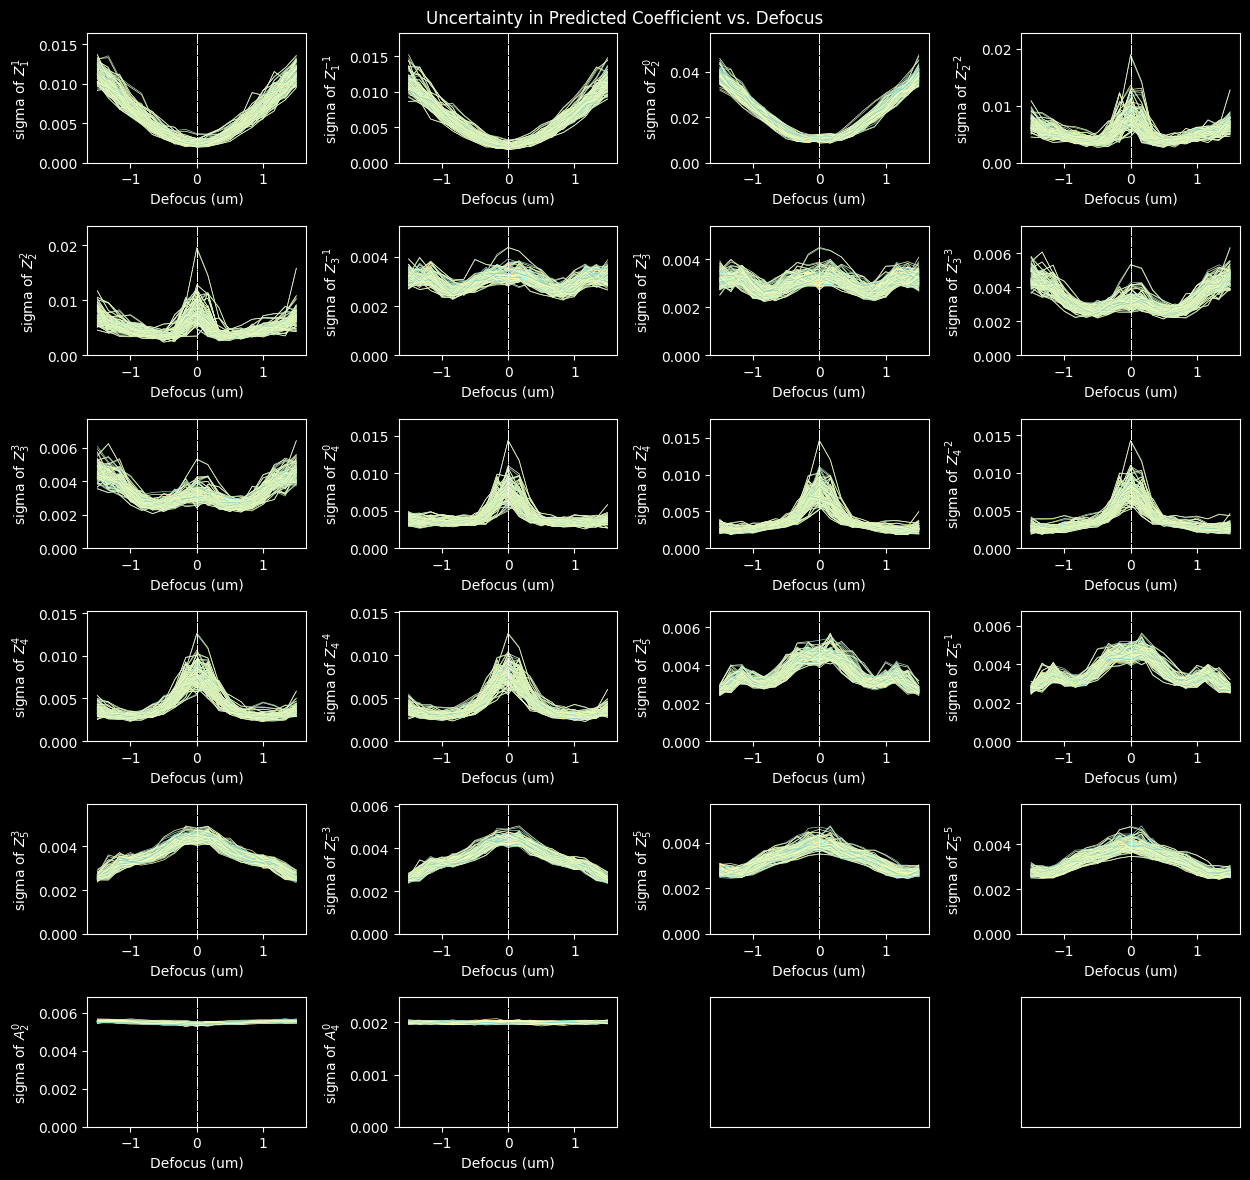

In [13]:
num_cols = 4
panel_size = 3
aspect_ratio = 0.7

num_coefs = solver.coefficients.num_nonpinned_coefs
num_rows = int(math.ceil(num_coefs / num_cols))
figsize = (panel_size * aspect_ratio * num_rows, panel_size * num_cols)

labels = solver.coefficients.nonpinned_labels

fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=figsize)
for i, ax in enumerate(axarr.ravel()):
    if i < num_coefs:
        for bidx, cidx in itertools.product(range(batch_size), range(solver.num_components)):
            ax.plot(z.numpy(force=True), sigmas[bidx, :, cidx, i].numpy(force=True), lw=0.5, color=f"C{cidx}")
            ax.set_ylabel(f"sigma of {labels[i]}")
            ax.set_xlabel("Defocus (um)")
            ax.axvline(0, ls=":", lw=0.5)
        max_val = sigmas[:, :, :, i].amax().numpy(force=True)
        ax.set_ylim(0, max_val * 1.2)
    else:
        ax.set_xticks([])
        ax.set_yticks([])
fig.suptitle("Uncertainty in Predicted Coefficient vs. Defocus")
fig.tight_layout()

##### Three classes of behavior appear:
1. Predictions with minimal uncertainty near z=0. These include the translation terms $Z_{1}^{\pm1}$; the defocus $Z_{2}^{0}$; and $Z_{3}^{\pm3}$. The translation makes sense based on wave physics: phase variations in the pupil (Fourier) plane are conjugate to momentum in the image/object planes, which
Heisenberg tells us becomes maximally uncertain when the beam's position is well-defined. Defocus being easiest to predict near z=0 also seems reasonable, since that's where the confounding influence from other shape-perturbing aberrations will be minimized. I'm not sure why $Z_{3}^{\pm3}$ show this trend, though.

2. Predictions with maximal uncertainty near z=0. This includes most of the shape-perturbing aberrations. The Fourier explanation from the previous point also applies here: in the far field (large defocus limit), the intensity distribution mirrors the angular spectrum, allowing angular frequency (and therefore, momentum) to be optimally resolved.

3. Predictions with no significant z-trend. This is primarily the amplitude terms, which just don't seem to be very impactful.

Calculate the Fisher information matrix (averaged over the batch) for each true defocus. This'll take a minute, Jacobians are expensive.

In [14]:
fisher_matrix_samples = []
coefs = solver.coefficients.gather_nonpinned(solver.coefficients.join(phase_coefs, amp_coefs))  # [B, C_kept]
for coefs_i in coefs:  # TODO - figure out a way to vectorize this later
    _, fisher_matrix = calculate_fisher_matrix(coefs_i, z, solver.simulator)
    fisher_matrix_samples.append(fisher_matrix.numpy(force=True))

num_coefs = solver.coefficients.num_nonpinned_coefs
fisher_matrix_samples = np.concatenate(fisher_matrix_samples)
fisher_matrix_samples = fisher_matrix_samples.reshape(batch_size, z.shape[0], num_coefs, num_coefs)  # [B, Z, C_kept, C_kept]
fisher_matrix = fisher_matrix_samples.mean(0)  # [Z, C_kept, C_kept]

Now plot the Fisher information matrix at each z. Kind of a fun visualization of how different coefficients have different relative levels of information at different z-positions. This is shown more quantitatively in the following plots.

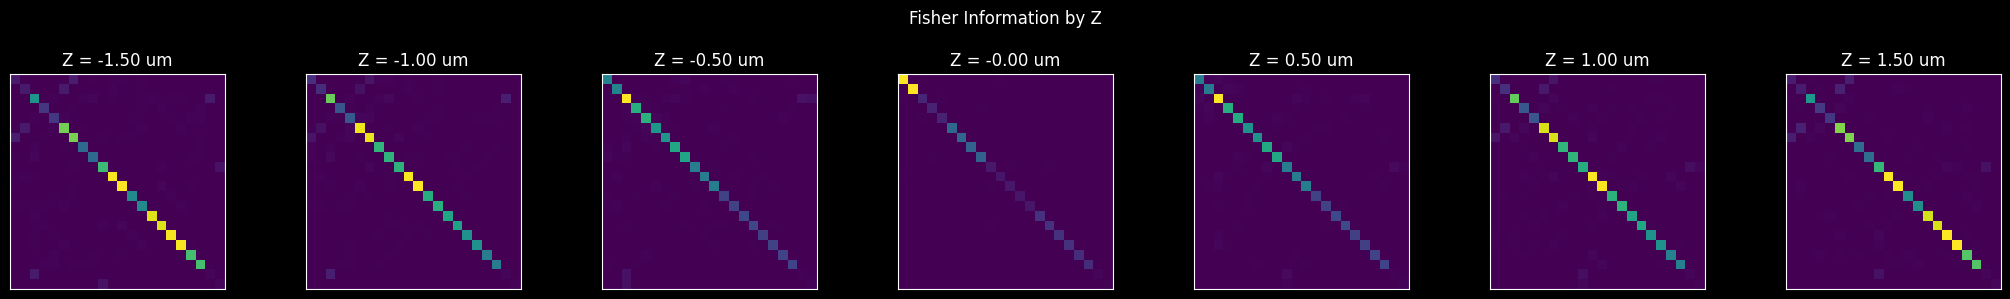

In [15]:
downsample = 3
fig = plot_stack(fisher_matrix[::downsample, :, :])  # misuse of `plot_stack`, but I won't tell anyone if you don't
for zval, ax in zip(z[::downsample], fig.axes):
    ax.set_title(f"Z = {float(zval):.2f} um")
fig.suptitle("Fisher Information by Z")
fig.tight_layout()

The van Trees bound gives the fundamental lower limit on how precisely a coefficient can be determined, based on its prior distribution and the sensitivity of the final image to it. For fun, overlay the predicted uncertainties from above so we can see how close the model got.

In [16]:
prior_sigmas = solver.coefficients.target_scales[~solver.coefficients.is_pinned].numpy(force=True)
prior_covariance = np.diag(prior_sigmas)**2
van_trees = calculate_van_trees_bounds(fisher_matrix, prior_covariance)

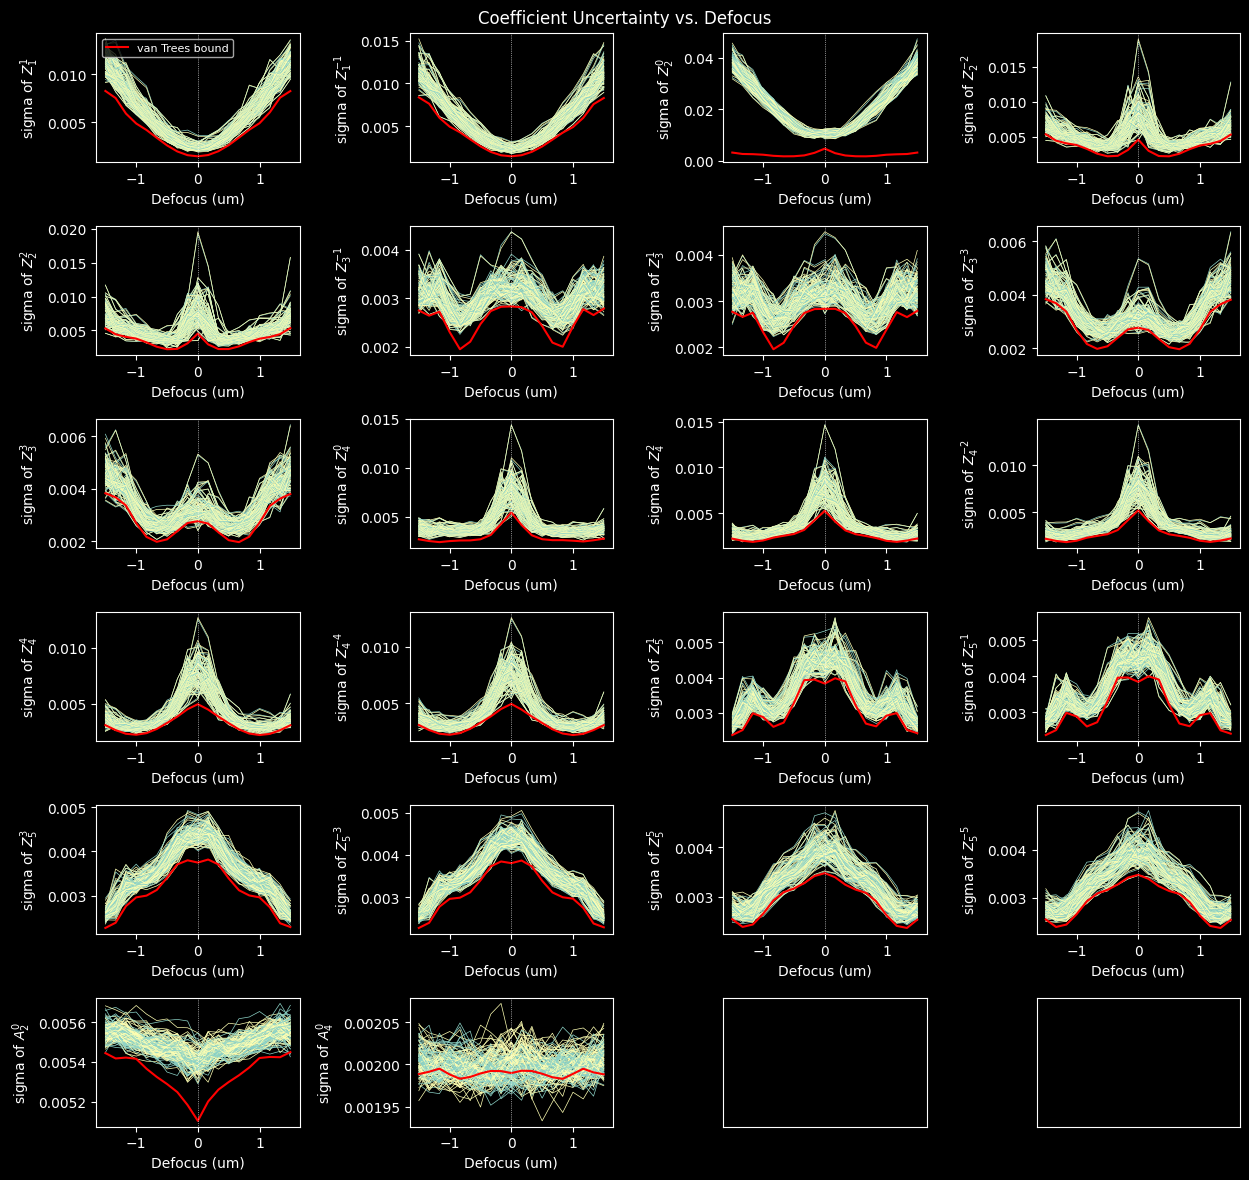

In [17]:
num_cols = 4
panel_size = 3
aspect_ratio = 0.7

num_coefs = solver.coefficients.num_nonpinned_coefs
num_rows = int(math.ceil(num_coefs / num_cols))
figsize = (panel_size * aspect_ratio * num_rows, panel_size * num_cols)

labels = solver.coefficients.nonpinned_labels

fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=figsize)
for i, ax in enumerate(axarr.ravel()):
    if i < num_coefs:
        for bidx, cidx in itertools.product(range(batch_size), range(solver.num_components)):
            ax.plot(z.numpy(force=True), sigmas[bidx, :, cidx, i].numpy(force=True), lw=0.5, color=f"C{cidx}")
        ax.plot(z.numpy(force=True), van_trees[:, i], color="r", label="van Trees bound")
        ax.set_ylabel(f"sigma of {labels[i]}")
        ax.set_xlabel("Defocus (um)")
        ax.axvline(0, ls=":", lw=0.5)
    else:
        ax.set_xticks([])
        ax.set_yticks([])
axarr[0, 0].legend(loc="upper left", fontsize=8)
fig.suptitle("Coefficient Uncertainty vs. Defocus")
fig.tight_layout()

In general, the predicted sigmas track  very nicely with the van Trees bound. The gap, usually ~10-50%, shows that the model isn't perfectly efficient. A few terms (most notably $Z_{2}^{0}$) show weirder effects that I need to think more about. Maybe something to do with how I'm folding the jittered defocus into the $Z_{2n}^{0}$ terms?

Finally, plot the van Trees bound, the predicted posterior (averaged over the batch), and the prior to see the impact of the model.

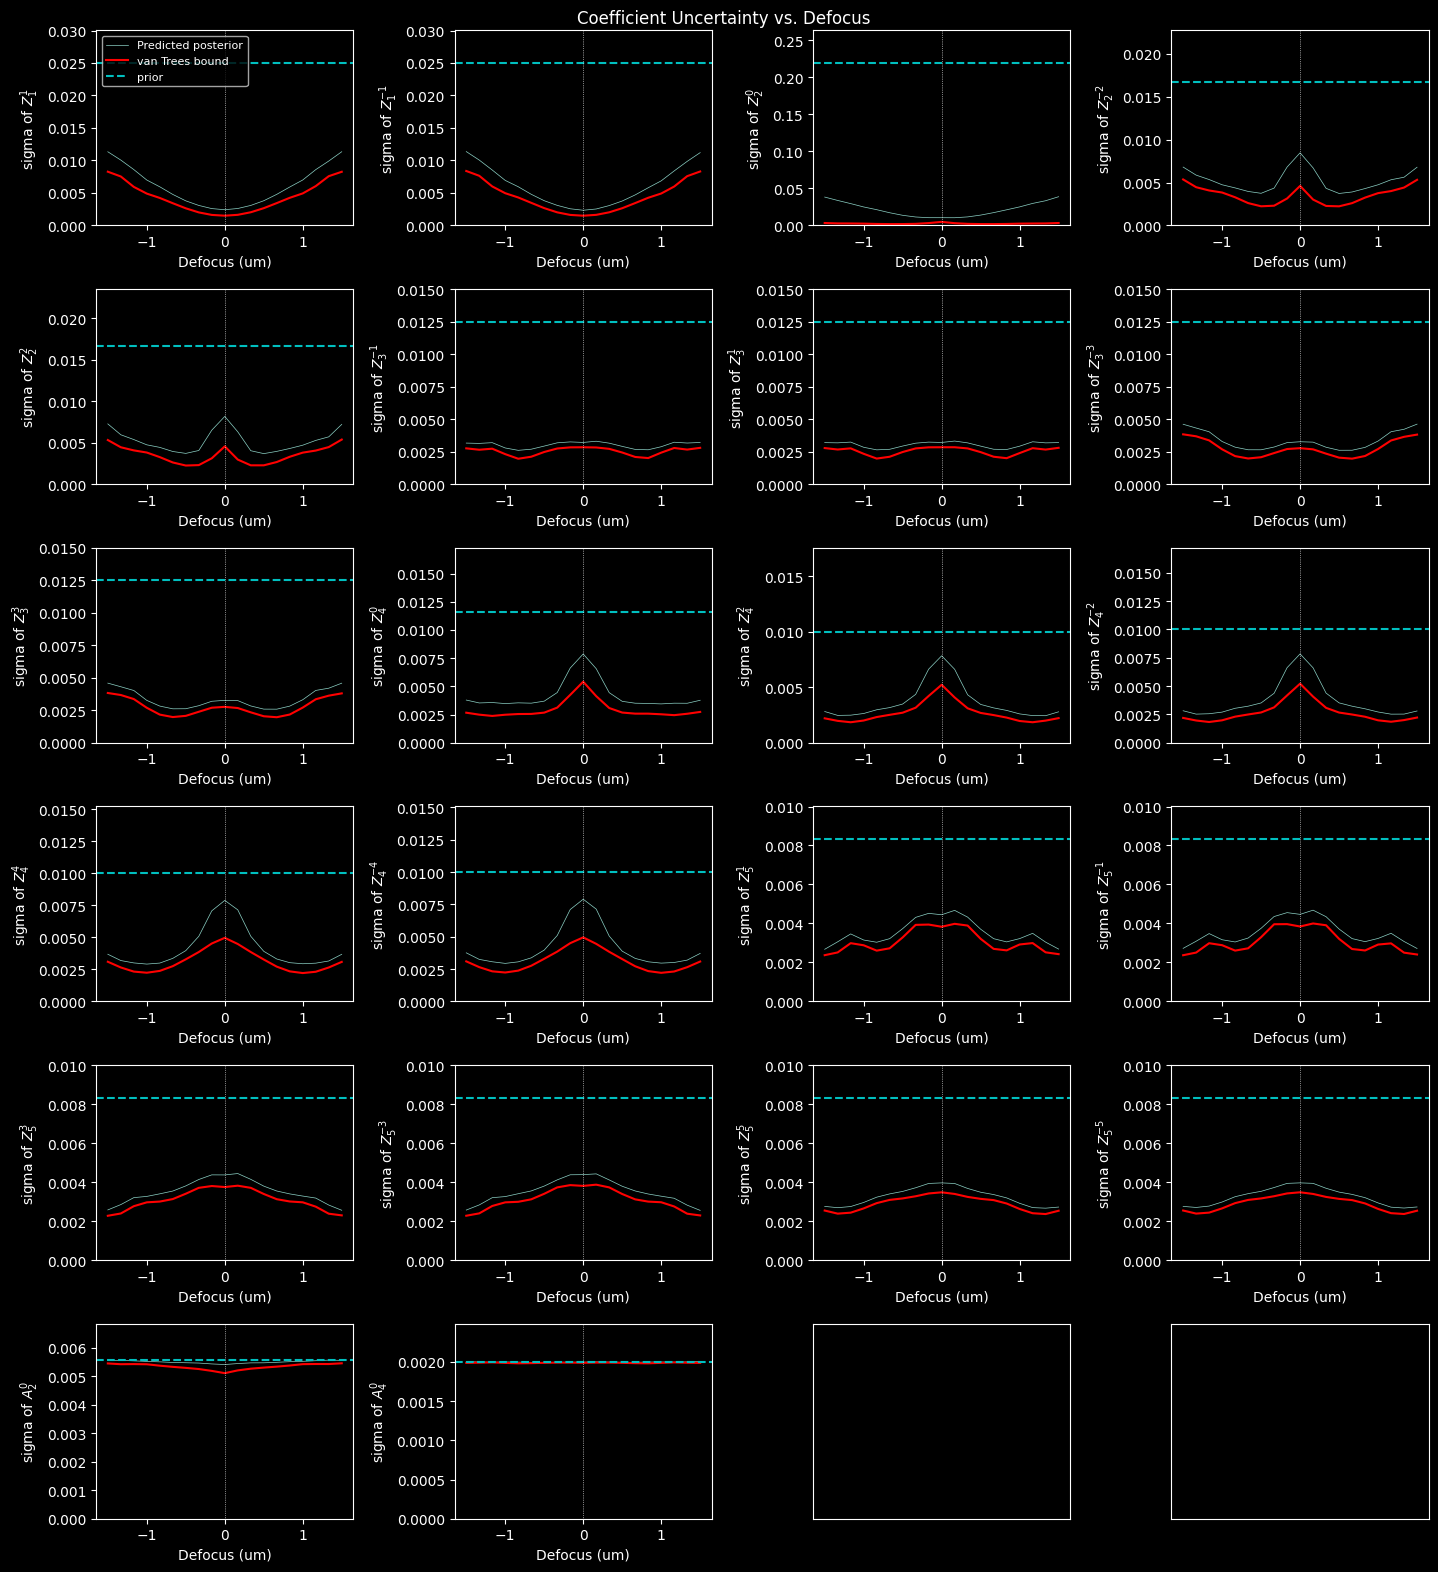

In [18]:
num_cols = 4
panel_size = 4
aspect_ratio = 0.6

num_coefs = solver.coefficients.num_nonpinned_coefs
num_rows = int(math.ceil(num_coefs / num_cols))
figsize = (panel_size * aspect_ratio * num_rows, panel_size * num_cols)

labels = solver.coefficients.nonpinned_labels

fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=figsize)
for i, ax in enumerate(axarr.ravel()):
    if i < num_coefs:
        ax.plot(z.numpy(force=True), sigmas[..., i].numpy(force=True).mean((0, 2)), lw=0.5, label="Predicted posterior")
        ax.plot(z.numpy(force=True), van_trees[:, i], color="r", label="van Trees bound")
        ax.axhline(prior_sigmas[i], ls="--", color="c", label="prior")

        max_val = max(sigmas[:, :, :, i].amax().numpy(force=True), van_trees[:, i].max(), prior_sigmas[i])
        ax.set_ylabel(f"sigma of {labels[i]}")
        ax.set_xlabel("Defocus (um)")
        ax.axvline(0, ls=":", lw=0.5)
        ax.set_ylim(0, max_val * 1.2)
    else:
        ax.set_xticks([])
        ax.set_yticks([])
axarr[0, 0].legend(loc="upper left", fontsize=8)
fig.suptitle("Coefficient Uncertainty vs. Defocus")
fig.tight_layout()

Clearly, the model is pushing the uncertainty from the prior down towards the van Trees limit in almost all cases (albeit non-uniformly). The exceptions, as mentioned earlier, are the amplitude cases, where the prior is basically overlapping with the van Trees limit to begin with. The model didn't learn anything because there was nothing to learn, these amplitude terms just aren't particularly constrained by the image data. There's a lesson in here somewhere about vignetting affecting intensity, but not resolution, in microscopy.